High Quality Filtered Datasets
This genotype-phenotype correlation dataset contains isolates on which in vitro susceptibility tests were performed using the PhenoSense assay (Monogram, South San Francisco, USA) (Zhang 2005). Redundant viruses obtained from the same individual that contained the same pattern of major drug resistance mutations (defined below) were excluded to minimize bias that would result from over-representing highly similar viruses. Viruses with sequences containing mixtures at these major drug resistance mutation positions were also excluded because the presence of mixtures at these positions may confound genotype-phenotype correlations.
PI Major Drug Resistance Positions: 30, 32, 47, 48, 50, 54, 76, 82, 84, 88
NRTI Major Drug Resistance Positions: 41, 65, 70, 74, 75, 151, 184, 210, 215
NNRTI Major Drug Resistance Positions: 100I, 101P, 103N, 106A/M, 181C/I/A, 188C/L/H, 190A/E/S/Q, 230L
INI Major Drug Resistance Positions: 66A/I/K, 92Q, 118R, 143, 148H/R/K, 155H, 263K
CAI Major Drug Resistance Positions: 56I, 57S, 66I, 67H/Y/N/K, 70R/S/N/H, 74D/S/K, 105T/E/S, 107N/C

In addition, the dataset can be read in directly over the web to the R script provided here. This R script contains a function which runs least squares regression on this dataset in cross-validations and generates two output files by default: (1) the coefficient and the standard error of each input mutation estimated from cross-validation runs; (2) the mean square error (MSE) estimated in each cross-validation run. The input parameters and additional options to this R function are documented in the script.

To access high quality filtered datasets from HIVDB by drug class, click the links below:

https://elifesciences.org/articles/106365



## Analysis workflow

This notebook walks through the HIV resistance analysis in five stages:

1. Build a reference FASTA containing the consensus protein sequences.
2. Load the HIV mutation-screen tables and summarize the number of mutations per entry.
3. Generate mutant protein sequences by applying the reported substitutions.
4. Run ESM3Di perplexity analysis on the native and mutant sequences.
5. Compare the resulting perplexity patterns with the experimental resistance measurements.


In [ ]:
consensus_seqs = '''
>protease
PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMNLPGRWKPKMIGGI
GGFIKVRQYDQILIEICGHKAIGTVLVGPTPVNIIGRNLLTQIGCTLNF

>RT
PISPIETVPVKLKPGMDGPKVKQWPLTEEKIKALVEICTEMEKEGKISKI
GPENPYNTPVFAIKKKDSTKWRKLVDFRELNKRTQDFWEVQLGIPHPAGL
KKKKSVTVLDVGDAYFSVPLDKDFRKYTAFTIPSINNETPGIRYQYNVLP
QGWKGSPAIFQSSMTKILEPFRKQNPDIVIYQYMDDLYVGSDLEIGQHRT
KIEELRQHLLRWGFTTPDKKHQKEPPFLWMGYELHPDKWTVQPIVLPEKD
SWTVNDIQKLVGKLNWASQIYAGIKVKQLCKLLRGTKALTEVIPLTEEAE
LELAENREILKEPVHGVYYDPSKDLIAEIQKQGQGQWTYQIYQEPFKNLK
TGKYARMRGAHTNDVKQLTEAVQKIATESIVIWGKTPKFKLPIQKETWEA
WWTEYWQATWIPEWEFVNTPPLVKLWYQLEKEPIVGAETFYVDGAANRET
KLGKAGYVTDRGRQKVVSLTDTTNQKTELQAIHLALQDSGLEVNIVTDSQ
YALGIIQAQPDKSESELVSQIIEQLIKKEKVYLAWVPAHKGIGGNEQVDK
LVSAGIRKVL 

>integrase
FLDGIDKAQEEHEKYHSNWRAMASDFNLPPVVAKEIVASCDKCQLKGEAM
HGQVDCSPGIWQLDCTHLEGKIILVAVHVASGYIEAEVIPAETGQETAYF
LLKLAGRWPVKTIHTDNGSNFTSTTVKAACWWAGIKQEFGIPYNPQSQGV
VESMNKELKKIIGQVRDQAEHLKTAVQMAVFIHNFKRKGGIGGYSAGERI
VDIIATDIQTKELQKQITKIQNFRVYYRDSRDPLWKGPAKLLWKGEGAVV
IQDNSDIKVVPRRKAKIIRDYGKQMAGDDCVASRQDED

>capsid
PIVQNLQGQMVHQAISPRTLNAWVKVVEEKAFSPEVIPMFSALSEGATPQ
DLNTMLNTVGGHQAAMQMLKETINEEAAEWDRLHPVHAGPIAPGQMREPR
GSDIAGTTSTLQEQIGWMTNNPPIPVGEIYKRWIILGLNKIVRMYSPTSI
LDIRQGPKEPFRDYVDRFYKTLRAEQASQEVKNWMTETLLVQNANPDCKT
ILKALGPAATLEEMMTACQGVGGPGHKARVL

'''

#output as a fasta file
with open("consensus_seqs.fasta", "w") as f:
	f.write(consensus_seqs)

In [ ]:
# Map each canonical sequence name to the relevant mutation-screen file(s)
# The RT sequence has separate NRTI and NNRTI datasets, while no dedicated
# integrase dataset is present in this folder.
mutation_screen_to_protein = {
	"protease": "PI_DataSet.txt",
	"RT": ["NRTI_DataSet.txt", "NNRTI_DataSet.txt"],
	"integrase": None,
	"capsid": "CAI_DataSet.txt",
}

mutation_screen_to_protein

{'protease': 'PI_DataSet.txt',
 'RT': ['NRTI_DataSet.txt', 'NNRTI_DataSet.txt'],
 'integrase': None,
 'capsid': 'CAI_DataSet.txt'}

## Step 2: Create mutant sequence files

The next step converts each mutation record into a full mutant protein sequence. This makes it possible to analyze the effect of each listed substitution using the language model instead of only looking at the raw mutation table.


In [ ]:
#read the text tables 
import pandas as pd
import glob

mutfiles = glob.glob("*.txt")
dfs = []
for mutfile in mutfiles:
	df = pd.read_csv(mutfile, sep="\t")
	print(f"File: {mutfile}")
	print(df.head())
	df["File"] = mutfile
	print(f"Columns in {mutfile}: {df.columns.tolist()}")
	print( df.CompMutList)
	df["NumMutations"] = df['CompMutList'].apply(lambda x: len(x.split(',')) if pd.notnull(x) else 0)
	dfs.append(df)
all_data = pd.concat(dfs, ignore_index=True)
print(f"Combined data shape: {all_data.shape}")

File: INI_DataSet.Full.txt
    SeqID   PtID Subtype      Method  RefID Type IsolateName SeqType   RAL  \
0  219526  11630       B  PhenoSense   2007  Lab        T66A     NaN   0.9   
1  219527  11630       B  PhenoSense   2007  Lab       S147G     NaN   1.1   
2  219528  11630       B  PhenoSense   2007  Lab       Q148H     NaN  15.0   
3  219529  11630       B  PhenoSense   2007  Lab       Q148K     NaN  37.0   
4  219530  11630       B  PhenoSense   2007  Lab       Q148R     NaN  29.0   

    EVG  ...  P280  P281  P282 P283 P284 P285 P286 P287 P288 CompMutList  
0   7.6  ...     -     -     -    -    -    -    -    -    -        T66A  
1   4.1  ...     -     -     -    -    -    -    -    -    -       S147G  
2   4.9  ...     -     -     -    -    -    -    -    -    -       Q148H  
3  94.0  ...     -     -     -    -    -    -    -    -    -       Q148K  
4  92.0  ...     -     -     -    -    -    -    -    -    -       Q148R  

[5 rows x 302 columns]
Columns in INI_DataSet.Full.tx

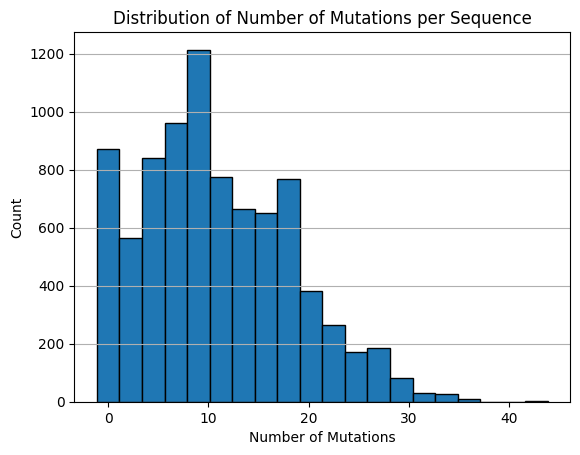

In [ ]:
#show a hist of the number of mutations per sequence
import matplotlib.pyplot as plt
plt.hist(all_data["NumMutations"], bins=20, align='left', edgecolor='black')
plt.xlabel("Number of Mutations")
plt.ylabel("Count")
plt.title("Distribution of Number of Mutations per Sequence")
plt.grid(axis='y')

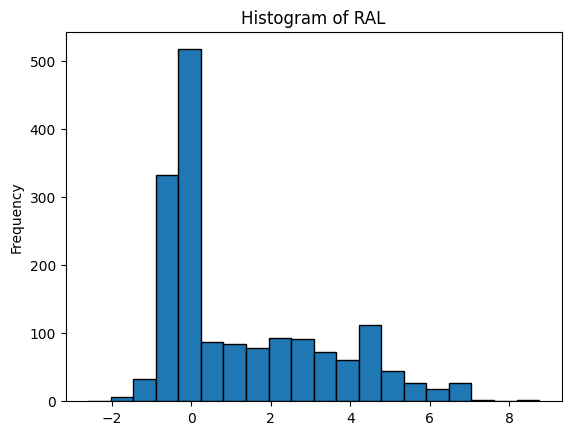

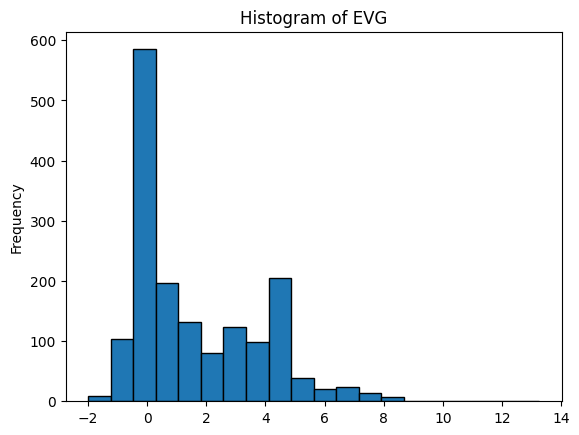

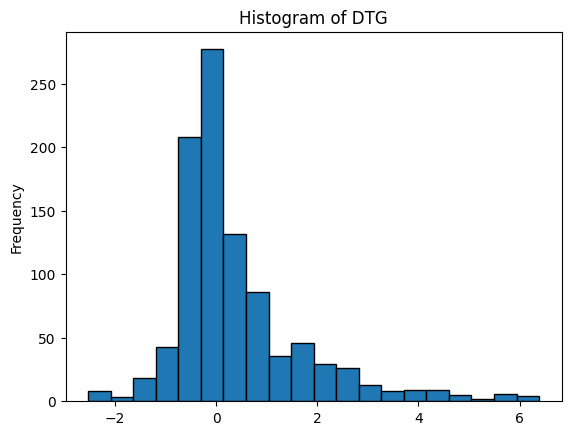

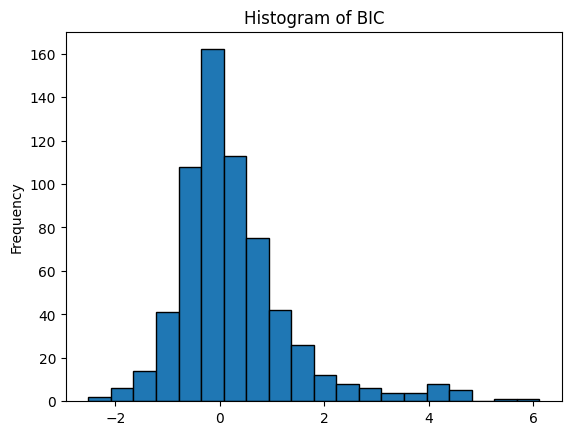

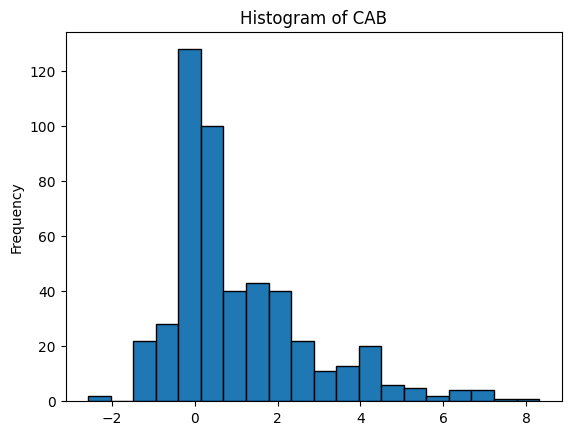

In [ ]:
import numpy as np
for val in [ 'RAL', 'EVG', 'DTG', 'BIC', 'CAB']:
	plt.hist(np.log(all_data[val][(all_data[val]>0) & (all_data[val].notna())]), bins=20, align='left', edgecolor='black')
	plt.title(f"Histogram of {val}")
	plt.ylabel("Frequency")
	plt.show()


In [ ]:
#create a fasta with the sequences in the mutation screen files
import os

def seqrow2newseq(seq, row):
	seq = list(seq)
	mut = row['CompMutList']
	muts = [m.strip() for m in (mut.split(',') if pd.notnull(mut) else [])]
	for m in muts:
		match = re.match(r'^([A-Za-z])(\d+)([A-Za-z])$', m)
		if not match:
			continue
		wt_aa = match.group(1).upper()
		pos = int(match.group(2))
		mut_aa = match.group(3).upper()
		if pos < 1 or pos > len(seq):
			raise ValueError(f"Position {pos} is out of bounds for sequence of length {len(seq)}")
		if seq[pos - 1] != wt_aa:
			raise ValueError(f"Wildtype amino acid at position {pos} is {seq[pos - 1]}, expected {wt_aa}")
		seq[pos - 1] = mut_aa
	return ''.join(seq)


with open('consensus_seqs.fasta', 'r') as f:
	fasta_lines = f.readlines()
fasta_dict = {}
current_protein = None
for line in fasta_lines:
	line = line.strip()
	print(line)
	if line.startswith('>'):
		current_protein = line[1:]
		fasta_dict[current_protein] = ''
	else:
		fasta_dict[current_protein] += line

for prot in mutation_screen_to_protein.keys():
	if mutation_screen_to_protein[prot] is None:
		continue
	files = mutation_screen_to_protein[prot]
	if isinstance(files, str):
		files = [files]
	for file in files:
		df = pd.read_csv(file, sep="\t")
		file_base = os.path.basename(file)
		with open(f"{prot}_{file_base}_mutations.fasta", "w") as f:
			for idx, row in df.iterrows():
				new_seq = seqrow2newseq(fasta_dict[prot], row)
				new_seq_id = row['SeqID']
				#assert newseq is not the old one
				if new_seq == fasta_dict[prot]:
					print(f"New sequence is the same as the original for SeqID {new_seq_id} in file {file}")
				else:
					f.write(f">{new_seq_id}\n")
					f.write(f"{new_seq}\n")


>protease
PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMNLPGRWKPKMIGGI
GGFIKVRQYDQILIEICGHKAIGTVLVGPTPVNIIGRNLLTQIGCTLNF

>RT
PISPIETVPVKLKPGMDGPKVKQWPLTEEKIKALVEICTEMEKEGKISKI
GPENPYNTPVFAIKKKDSTKWRKLVDFRELNKRTQDFWEVQLGIPHPAGL
KKKKSVTVLDVGDAYFSVPLDKDFRKYTAFTIPSINNETPGIRYQYNVLP
QGWKGSPAIFQSSMTKILEPFRKQNPDIVIYQYMDDLYVGSDLEIGQHRT
KIEELRQHLLRWGFTTPDKKHQKEPPFLWMGYELHPDKWTVQPIVLPEKD
SWTVNDIQKLVGKLNWASQIYAGIKVKQLCKLLRGTKALTEVIPLTEEAE
LELAENREILKEPVHGVYYDPSKDLIAEIQKQGQGQWTYQIYQEPFKNLK
TGKYARMRGAHTNDVKQLTEAVQKIATESIVIWGKTPKFKLPIQKETWEA
WWTEYWQATWIPEWEFVNTPPLVKLWYQLEKEPIVGAETFYVDGAANRET
KLGKAGYVTDRGRQKVVSLTDTTNQKTELQAIHLALQDSGLEVNIVTDSQ
YALGIIQAQPDKSESELVSQIIEQLIKKEKVYLAWVPAHKGIGGNEQVDK
LVSAGIRKVL

>integrase
FLDGIDKAQEEHEKYHSNWRAMASDFNLPPVVAKEIVASCDKCQLKGEAM
HGQVDCSPGIWQLDCTHLEGKIILVAVHVASGYIEAEVIPAETGQETAYF
LLKLAGRWPVKTIHTDNGSNFTSTTVKAACWWAGIKQEFGIPYNPQSQGV
VESMNKELKKIIGQVRDQAEHLKTAVQMAVFIHNFKRKGGIGGYSAGERI
VDIIATDIQTKELQKQITKIQNFRVYYRDSRDPLWKGPAKLLWKGEGAVV
IQDNSDIKVVPRRKAKIIRDYGKQMAGDDCVASRQDED

>caps

In [ ]:
# look at perplexity for each mutation

# load the esm3di model

from pathlib import Path
import importlib.util
import sys
import types
import torch

notebook_root = Path.cwd().resolve()
if (notebook_root / "esm3di" / "ESM3di_model.py").exists():
	repo_root = notebook_root
elif (notebook_root.parent / "esm3di" / "ESM3di_model.py").exists():
	repo_root = notebook_root.parent
else:
	raise FileNotFoundError("Could not locate the esm3di package relative to the notebook working directory")

module_path = repo_root / "esm3di" / "ESM3di_model.py"
package_path = repo_root / "esm3di"

package_name = "esm3di"
if package_name not in sys.modules:
	package_module = types.ModuleType(package_name)
	package_module.__path__ = [str(package_path)]
	sys.modules[package_name] = package_module

spec = importlib.util.spec_from_file_location("esm3di.ESM3di_model", module_path)
esm3di_model = importlib.util.module_from_spec(spec)
sys.modules["esm3di.ESM3di_model"] = esm3di_model
assert spec.loader is not None
spec.loader.exec_module(esm3di_model)

ESM3DiModel = esm3di_model.ESM3DiModel
read_fasta = esm3di_model.read_fasta

MODEL_CKPT = "../checkpoints/esm3di_from_mlm/epoch_5.pt"
requested_revision = "46c5f7d"

print("Loading model configuration from checkpoint...")
checkpoint = torch.load(MODEL_CKPT, map_location="cpu")

args_dict = checkpoint.get('args', {})
hf_model_name = args_dict.get(
	'hf_model_name',
	args_dict.get('hf_model', 'facebook/esm2_t33_650M_UR50D')
)
#use the model name from the checkpoint if available, otherwise use a default


resolved_model_revision = args_dict.get("revision", requested_revision)
print(f"Using model: {hf_model_name}")
print(f"Using model revision: {resolved_model_revision}")

label_vocab = checkpoint.get("label_vocab") or []
num_labels = len(label_vocab) or int(args_dict.get("num_labels", 20))
idx2char = {i: c for i, c in enumerate(label_vocab)}
print(f"Loaded {num_labels} labels")

use_cnn_head = bool(args_dict.get("use_cnn_head", False))
use_transformer_head = bool(args_dict.get("use_transformer_head", False))
use_plddt_prediction_head = bool(args_dict.get("use_plddt_prediction_head", False))
plddt_prediction_mode = args_dict.get("plddt_prediction_mode", "classification")
lora_r = args_dict.get("lora_r", 8)
lora_alpha = args_dict.get("lora_alpha", 16)
lora_dropout = args_dict.get("lora_dropout", 0.05)
target_modules = checkpoint.get("lora_target_modules", args_dict.get("target_modules"))

print("Model configuration:")
print(f"  cnn_head={use_cnn_head}")
print(f"  transformer_head={use_transformer_head}")
print(f"  plddt_head={use_plddt_prediction_head} ({plddt_prediction_mode})")
print(f"  lora_r={lora_r}, lora_alpha={lora_alpha}, lora_dropout={lora_dropout}")
print(f"  target_modules={'auto-discover' if target_modules is None else target_modules}")

model = ESM3DiModel(
	hf_model_name=hf_model_name,
	revision=resolved_model_revision,
	num_labels=num_labels,
	lora_r=lora_r,
	lora_alpha=lora_alpha,
	lora_dropout=lora_dropout,
	target_modules=target_modules,
	use_cnn_head=use_cnn_head,
	cnn_num_layers=args_dict.get("cnn_num_layers", 2),
	cnn_kernel_size=args_dict.get("cnn_kernel_size", 3),
	cnn_dropout=args_dict.get("cnn_dropout", 0.1),
	use_transformer_head=use_transformer_head,
	use_plddt_prediction_head=use_plddt_prediction_head,
	plddt_num_bins=args_dict.get("plddt_num_bins", len(checkpoint.get("plddt_label_vocab") or []) or 10),
	plddt_prediction_mode=plddt_prediction_mode,
	transformer_head_dim=args_dict.get("transformer_head_dim", 256),
	transformer_head_layers=args_dict.get("transformer_head_layers", 2),
	transformer_head_dropout=args_dict.get("transformer_head_dropout", 0.1),
	transformer_head_num_heads=args_dict.get("transformer_head_num_heads", None),
	use_iterative_transformer_head=args_dict.get("use_iterative_transformer_head", False),
	iterative_head_max_iterations=args_dict.get("iterative_head_max_iterations", 5),
	iterative_head_halt_threshold=args_dict.get("iterative_head_halt_threshold", 0.95),
	iterative_head_lambda_p=args_dict.get("iterative_head_lambda_p", 0.01),
	iterative_head_prior_p=args_dict.get("iterative_head_prior_p", 0.5),
	use_positional_encoding=args_dict.get("use_positional_encoding", True),
	use_hidden_state_feedback=args_dict.get("use_hidden_state_feedback", True),
	use_gru_gate=args_dict.get("use_gru_gate", False),
	aux_track_num_bins=checkpoint.get("aux_track_num_bins", args_dict.get("aux_track_num_bins", None)),
 )

print(f"Model object created: {type(model).__name__}")
print(f"Underlying model wrapper: {type(model.get_model()).__name__ if hasattr(model, 'get_model') else 'n/a'}")

/home/dmoi/miniforge3/envs/fastas2foldseekdb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading model configuration from checkpoint...
Using model: Synthyra/ESMplusplus_small
Using model revision: 46c5f7d
Loaded 20 labels
Model configuration:
  cnn_head=True
  transformer_head=False
  plddt_head=False (regression)
  lora_r=16, lora_alpha=32.0, lora_dropout=0.01
  target_modules=auto-discover

Loading model: Synthyra/ESMplusplus_small


Attention backend: config='sdpa' -> resolved='sdpa'


Loading weights: 100%|██████████| 308/308 [00:00<00:00, 1942.40it/s]
[transformers] ESMplusplusForTokenClassification LOAD REPORT from: Synthyra/ESMplusplus_small
Key                         | Status  | 
----------------------------+---------+-
classifier.{0, 2, 3}.bias   | MISSING | 
classifier.{0, 2, 3}.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Base model loaded (TokenClassification)

Auto-discovering LoRA target modules...
Discovering LoRA target modules...
Discovered target modules: ['classifier.0', 'classifier.3', 'embed', 'sequence_head.0', 'sequence_head.3', 'transformer.blocks.0.attn.layernorm_qkv.1', 'transformer.blocks.0.attn.out_proj', 'transformer.blocks.0.ffn.1', 'transformer.blocks.0.ffn.3', 'transformer.blocks.1.attn.layernorm_qkv.1', 'transformer.blocks.1.attn.out_proj', 'transformer.blocks.1.ffn.1', 'transformer.blocks.1.ffn.3', 'transformer.blocks.10.attn.layernorm_qkv.1', 'transformer.blocks.10.attn.out_proj', 'transformer.blocks.10.ffn.1', 'transformer.blocks.10.ffn.3', 'transformer.blocks.11.attn.layernorm_qkv.1', 'transformer.blocks.11.attn.out_proj', 'transformer.blocks.11.ffn.1', 'transformer.blocks.11.ffn.3', 'transformer.blocks.12.attn.layernorm_qkv.1', 'transformer.blocks.12.attn.out_proj', 'transformer.blocks.12.ffn.1', 'transformer.blocks.12.ffn.3', 'transformer.blocks.13.attn.layernorm_qkv.1', 't

## Perplexity analysis of native and mutant 3Di sequences

This section runs the native 3Di perplexity baseline on the consensus sequences, then runs the saturation mutation screen and compares mutation positions from the HIV data against the native sequence background.

In [ ]:
from pathlib import Path
import re
import pandas as pd
from IPython.display import display

native_fasta = Path("consensus_seqs.fasta")
native_perplexity_tsv = Path("HIV_native_perplexity.tsv")
mutation_screen_tsv = Path("HIV_mutation_screen.tsv")

if not native_fasta.exists():
	raise FileNotFoundError(f"Missing native FASTA: {native_fasta.resolve()}")

print("Running native per-position perplexity analysis...")
native_perplexity_records = model.output_per_position_perplexity_from_fasta(
	input_fasta_path=str(native_fasta),
	output_tsv_path=str(native_perplexity_tsv),
	model_checkpoint_path=MODEL_CKPT,
	batch_size=2,
	device=None,
 )

native_perplexity_df = pd.read_csv(native_perplexity_tsv, sep="\t")
display(native_perplexity_df.head())

print("Running saturation mutation screen...")
mutation_screen_records = model.mutation_screen_perplexity_from_fasta(
	input_fasta_path=str(native_fasta),
	output_tsv_path=str(mutation_screen_tsv),
	model_checkpoint_path=MODEL_CKPT,
	batch_size=2,
	device=None,
 )

mutation_screen_df = pd.read_csv(mutation_screen_tsv, sep="\t")
display(mutation_screen_df.head())

Running native per-position perplexity analysis...
Using device: cuda
Loading model from: ../checkpoints/esm3di_from_mlm/epoch_5.pt
✓ Checkpoint loaded
✓ Loaded model from epoch 5


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Reading input FASTA: consensus_seqs.fasta
Found 4 sequences
Writing per-position perplexity TSV to: HIV_native_perplexity.tsv
Processed 4/4 sequences
✓ Per-position perplexity complete! 4 sequences written to HIV_native_perplexity.tsv


,sequence_id,position,aa,perplexity
0,protease,1,P,1.002843
1,protease,2,Q,2.437861
2,protease,3,I,2.547036
3,protease,4,T,2.411217
4,protease,5,L,3.168392


Running saturation mutation screen...
Using device: cuda
Loading model from: ../checkpoints/esm3di_from_mlm/epoch_5.pt
✓ Checkpoint loaded
✓ Loaded model from epoch 5
Reading input FASTA: consensus_seqs.fasta
Found 4 sequences
Generated 22382 single-site mutants
Writing mutation screen TSV to: HIV_mutation_screen.tsv
Processed 20/22382 mutants
Processed 40/22382 mutants
Processed 60/22382 mutants
Processed 80/22382 mutants
Processed 100/22382 mutants
Processed 120/22382 mutants
Processed 140/22382 mutants
Processed 160/22382 mutants
Processed 180/22382 mutants
Processed 200/22382 mutants
Processed 220/22382 mutants
Processed 240/22382 mutants
Processed 260/22382 mutants
Processed 280/22382 mutants
Processed 300/22382 mutants
Processed 320/22382 mutants
Processed 340/22382 mutants
Processed 360/22382 mutants
Processed 380/22382 mutants
Processed 400/22382 mutants
Processed 420/22382 mutants
Processed 440/22382 mutants
Processed 460/22382 mutants
Processed 480/22382 mutants
Processed 500

,sequence_id,position,original_aa,mutant_aa,n_other_positions,min_perplexity,max_perplexity,mean_perplexity,variance_perplexity,skewness_perplexity,kurtosis_perplexity
0,protease,1,P,A,98,1.001180,4.875631,2.268248,0.843263,0.660310,-0.235215
1,protease,1,P,C,98,1.001224,4.953662,2.262696,0.839670,0.684136,-0.149948
2,protease,1,P,D,98,1.001311,4.949649,2.279304,0.867556,0.660457,-0.237678
3,protease,1,P,E,98,1.001212,4.893404,2.272610,0.858137,0.671633,-0.218536
4,protease,1,P,F,98,1.001380,4.881289,2.271841,0.843896,0.663458,-0.222625


## Step 4: Perplexity analysis

This section evaluates the model’s native sequence perplexity and then runs the mutation-screen analysis. The goal is to quantify how strongly each substitution changes the model’s confidence in the sequence.


In [ ]:
#calculate perplexity for each sequence in the mutation screen files

mutation_fastas = glob.glob("*_mutations.fasta")
for fasta_file in mutation_fastas:
	print(f"Calculating perplexity for {fasta_file}...")
	output_tsv = fasta_file.replace(".fasta", "_perplexity.tsv")
	model.output_per_position_perplexity_from_fasta(
		input_fasta_path=fasta_file,
		output_tsv_path=output_tsv,
		model_checkpoint_path=MODEL_CKPT,
		batch_size=2,
		device=None,
	)
	print(f"Perplexity results saved to {output_tsv}")

Calculating perplexity for protease_PI_DataSet.txt_mutations.fasta...
Using device: cuda
Loading model from: ../checkpoints/esm3di_from_mlm/epoch_5.pt
✓ Checkpoint loaded
✓ Loaded model from epoch 5
Reading input FASTA: protease_PI_DataSet.txt_mutations.fasta
Found 2154 sequences
Writing per-position perplexity TSV to: protease_PI_DataSet.txt_mutations_perplexity.tsv
Processed 20/2154 sequences
Processed 40/2154 sequences
Processed 60/2154 sequences
Processed 80/2154 sequences
Processed 100/2154 sequences
Processed 120/2154 sequences
Processed 140/2154 sequences
Processed 160/2154 sequences
Processed 180/2154 sequences
Processed 200/2154 sequences
Processed 220/2154 sequences
Processed 240/2154 sequences
Processed 260/2154 sequences
Processed 280/2154 sequences
Processed 300/2154 sequences
Processed 320/2154 sequences
Processed 340/2154 sequences
Processed 360/2154 sequences
Processed 380/2154 sequences
Processed 400/2154 sequences
Processed 420/2154 sequences
Processed 440/2154 sequen

Native perplexity for protease: 1.002843


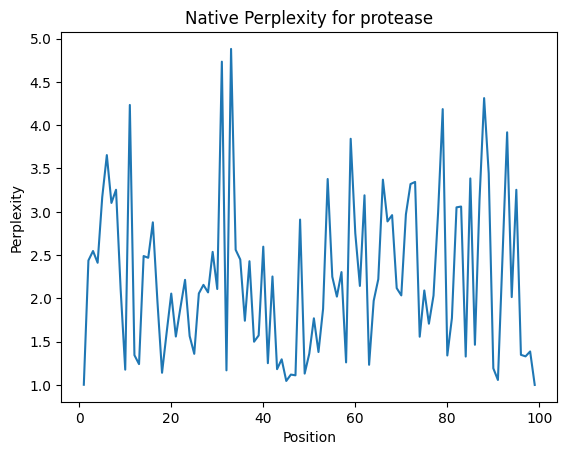

Native perplexity for RT: 1.004165


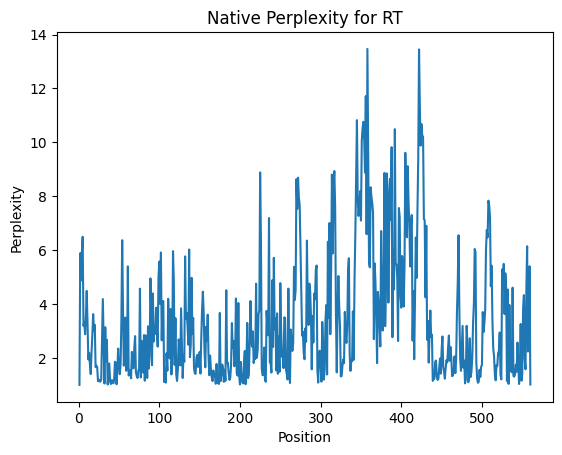

Native perplexity for integrase: 1.019138


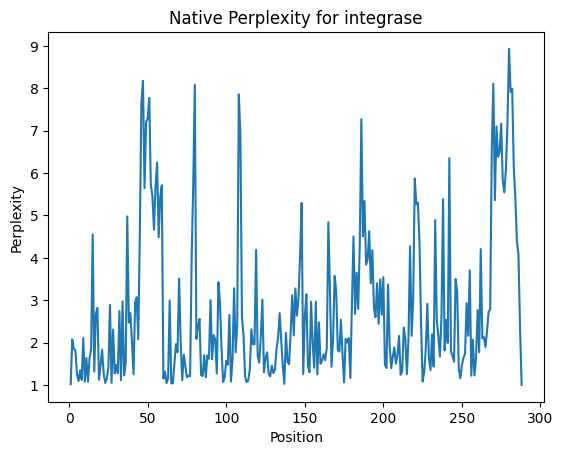

Native perplexity for capsid: 1.00507


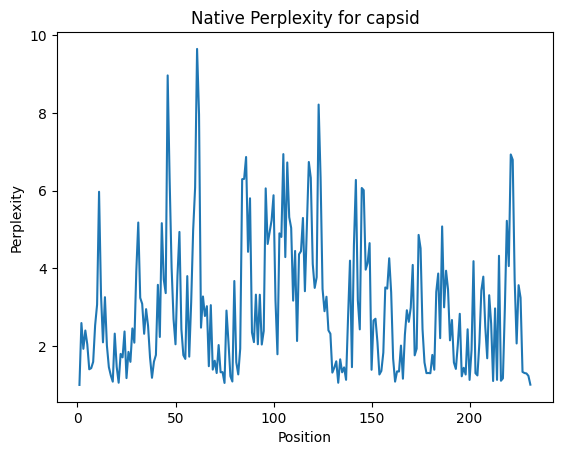

In [9]:
#show native perplexity for each protein
native_perplexity_df = pd.read_csv("HIV_native_perplexity.tsv", sep="\t")
for protein in native_perplexity_df['sequence_id'].unique():
	sub_native_perplexity = native_perplexity_df[native_perplexity_df['sequence_id'] == protein]['perplexity'].values[0]
	print(f"Native perplexity for {protein}: {sub_native_perplexity}")
	plt.plot(native_perplexity_df[native_perplexity_df['sequence_id'] == protein]['position'], native_perplexity_df[native_perplexity_df['sequence_id'] == protein]['perplexity'], label=f"{protein} native perplexity")
	plt.xlabel("Position")
	plt.ylabel("Perplexity")
	plt.title(f"Native Perplexity for {protein}")
	plt.show()

Native perplexity for PI: 1.00507
Perplexity summary for PI:
   sequence_id  mean_perplexity  variance_perplexity  median_perplexity  \
0         2996         2.253081             0.888442           2.058130   
1         4387         2.275996             0.865827           2.080918   
2         4426         2.239262             0.884212           2.049290   
3         4432         2.262677             0.864178           2.067218   
4         4482         2.235529             0.885375           2.056571   

   kurtosis_perplexity  skewness_perplexity  max_perplexity  min_perplexity  
0            -0.435460             0.657277        4.850145        1.001166  
1            -0.843914             0.486709        4.478037        1.001206  
2            -0.396857             0.671504        4.828003        1.001054  
3            -0.694406             0.538863        4.497027        1.001155  
4            -0.502674             0.657747        4.709476        1.001184  
Merged dataframe for

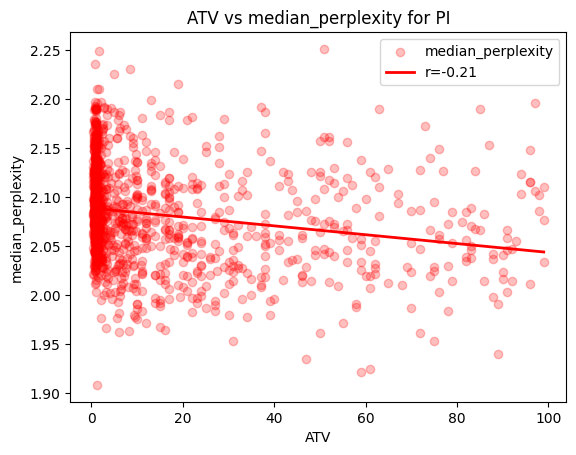

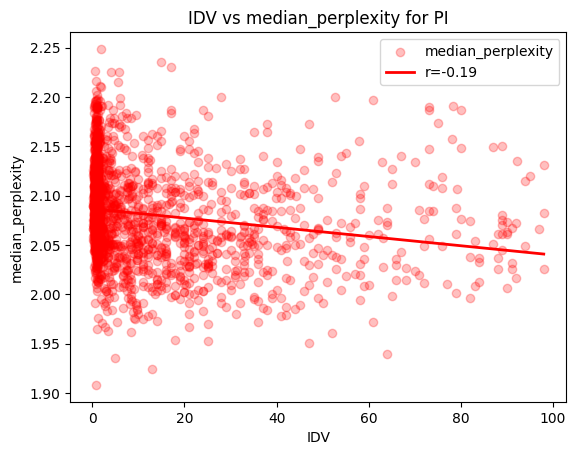

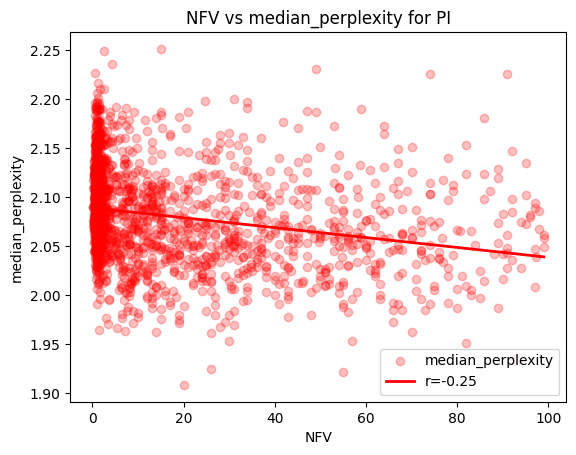

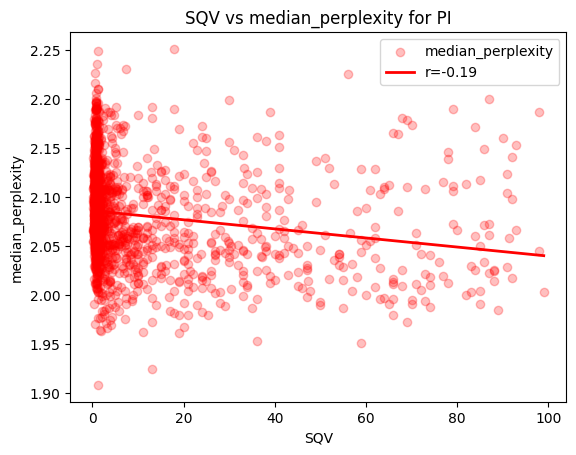

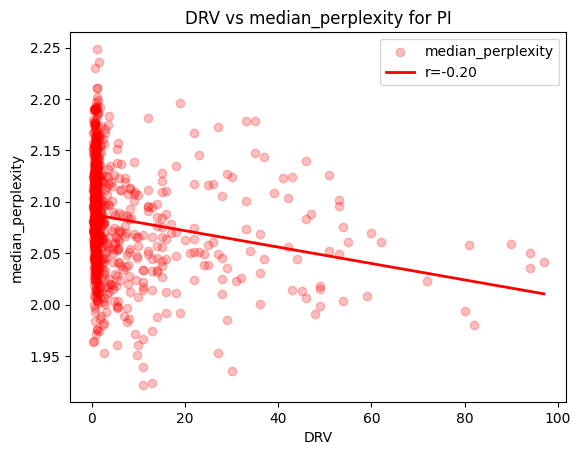

Native perplexity for CAI: 1.00507
Perplexity summary for CAI:
   sequence_id  mean_perplexity  variance_perplexity  median_perplexity  \
0       749356         3.024674             3.004994           2.585590   
1       749358         3.019747             2.992568           2.586442   
2       749359         3.024674             3.004994           2.585590   
3       749360         3.009622             2.969601           2.516239   
4       749361         3.021993             3.011166           2.593570   

   kurtosis_perplexity  skewness_perplexity  max_perplexity  min_perplexity  
0             0.949793             1.121125        9.677870        1.005211  
1             0.991778             1.128127        9.672507        1.005136  
2             0.949793             1.121125        9.677870        1.005211  
3             1.082527             1.142408        9.703806        1.004995  
4             1.038626             1.140866        9.620250        1.005247  
Merged dataframe f

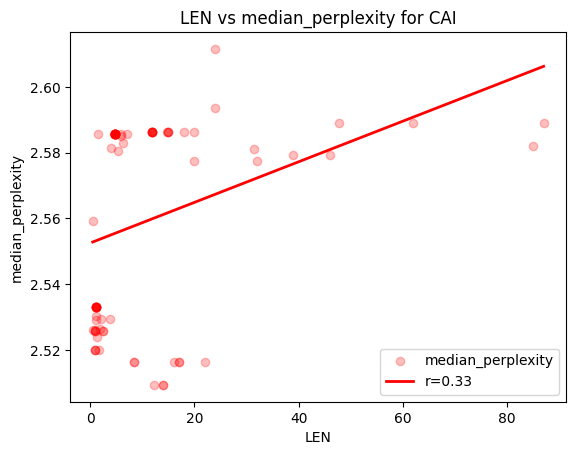

Native perplexity for NNRTI: 1.00507
Perplexity summary for NNRTI:
   sequence_id  mean_perplexity  variance_perplexity  median_perplexity  \
0         4388         3.415289             5.621786           2.647748   
1         4427         3.387119             5.561226           2.617783   
2         4433         3.410500             5.658677           2.648335   
3         4483         3.411753             5.633212           2.613951   
4         4487         3.412056             5.657100           2.634366   

   kurtosis_perplexity  skewness_perplexity  max_perplexity  min_perplexity  
0             1.701585             1.414484       13.450974        1.004463  
1             1.927960             1.455641       13.643583        1.004125  
2             1.784925             1.433847       13.627237        1.004228  
3             1.688699             1.418753       13.465301        1.004273  
4             1.679378             1.417199       13.460008        1.004688  
Merged datafra

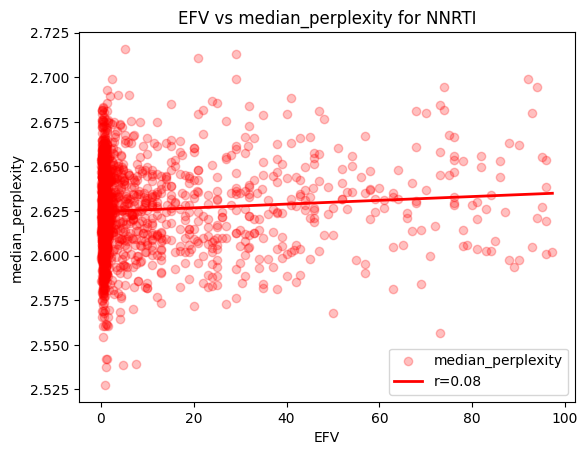

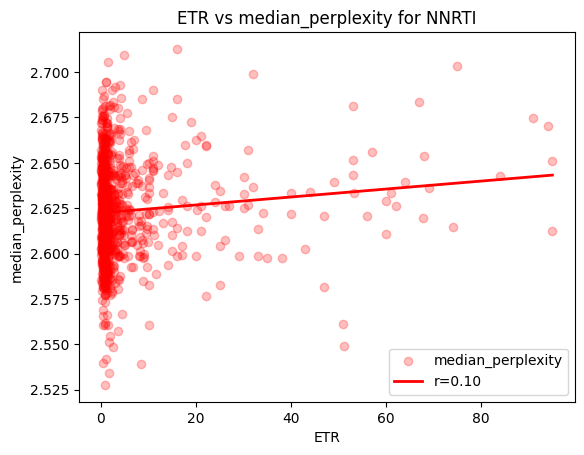

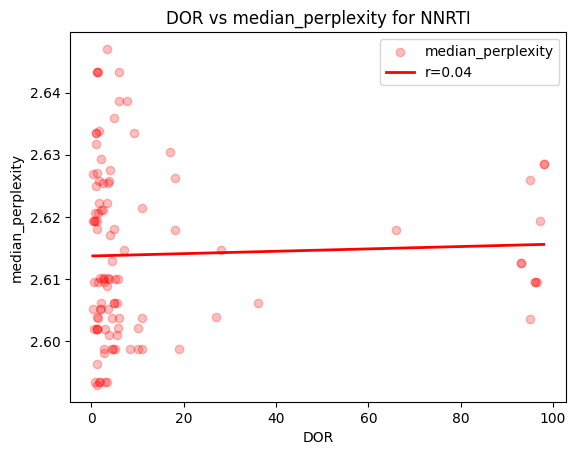

Native perplexity for NRTI: 1.00507
Perplexity summary for NRTI:
   sequence_id  mean_perplexity  variance_perplexity  median_perplexity  \
0         2997         3.430106             5.623635           2.665411   
1         4388         3.415289             5.621786           2.647748   
2         4427         3.387119             5.561226           2.617783   
3         4487         3.412056             5.657100           2.634366   
4         4539         3.415344             5.616317           2.620093   

   kurtosis_perplexity  skewness_perplexity  max_perplexity  min_perplexity  
0             1.675133             1.401908       13.481776        1.004640  
1             1.701585             1.414484       13.450974        1.004463  
2             1.927960             1.455641       13.643583        1.004125  
3             1.679378             1.417199       13.460008        1.004688  
4             1.658884             1.409430       13.377473        1.004377  
Merged dataframe

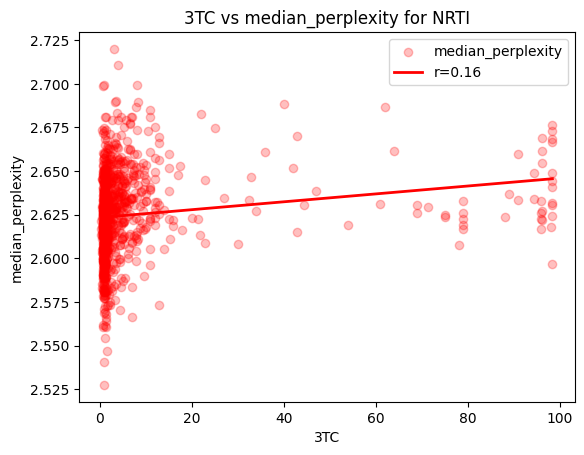

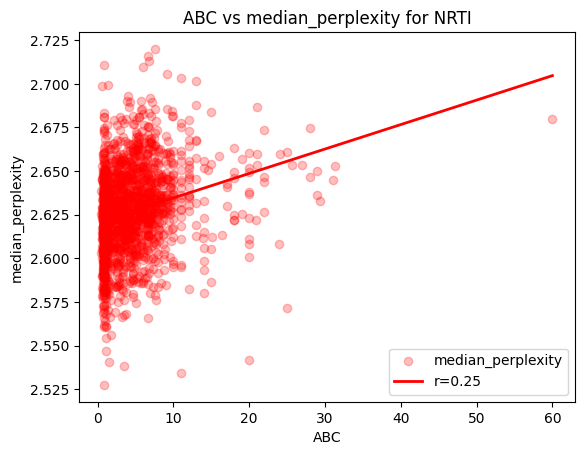

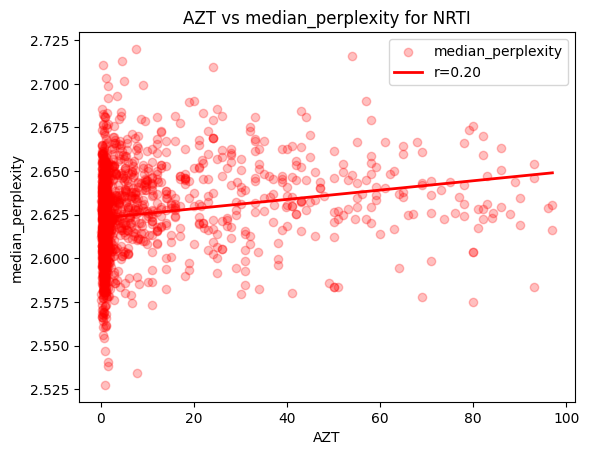

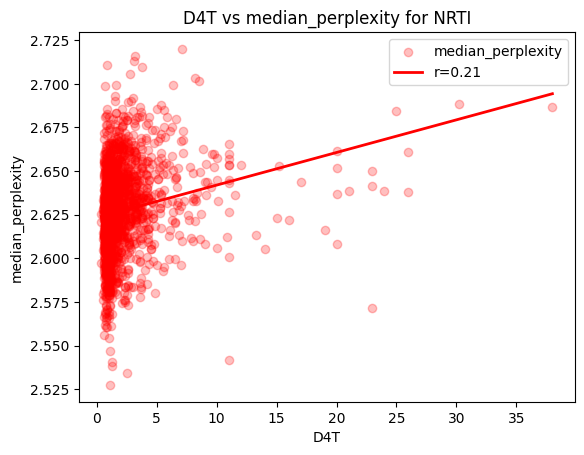

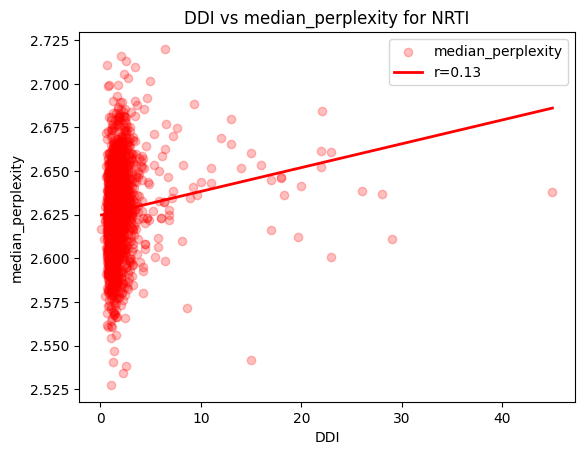

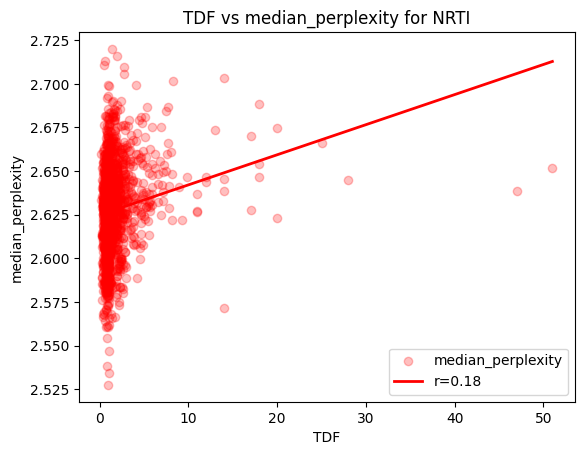

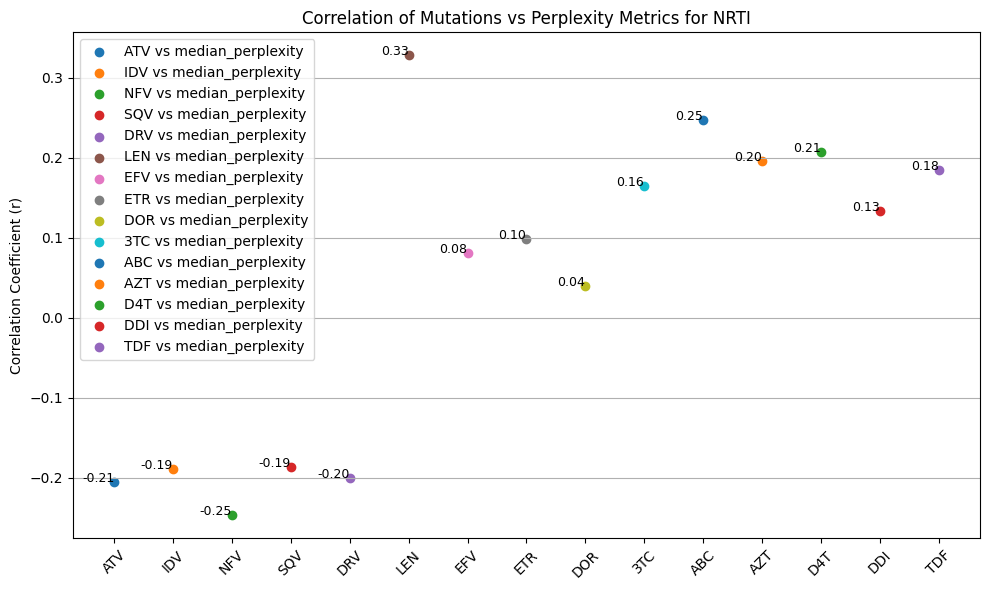

In [13]:
#make a plot of sequence perplexity vs the 'RAL', 'EVG', 'DTG', 'BIC', 'CAB' values found in the mutation screen files
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


mutation_screen_files = glob.glob("*DataSet.txt")
perplexity_files = glob.glob("*_mutations_perplexity.tsv")
native_perplexity_files = pd.read_csv("HIV_native_perplexity.tsv", sep="\t")

mutation_screen_dataset = { m.split('_')[0]: m for m in mutation_screen_files }
perplexity_dataset = { p.split('_')[1]: p for p in perplexity_files }

rvals = []

for m in mutation_screen_dataset:
	if m in perplexity_dataset:
		df_screen = pd.read_csv(mutation_screen_dataset[m], sep="\t")
		protein = m
		df_perplexity = pd.read_csv(perplexity_dataset[m], sep="\t")



		print(f"Native perplexity for {protein}: {sub_native_perplexity}")

		#compile summary statistics for the perplexity dataframe for each sequence
		df_perplexity_summary = df_perplexity.groupby('sequence_id').agg(
			mean_perplexity=('perplexity', 'mean'),
			variance_perplexity=('perplexity', 'var'),
			median_perplexity=('perplexity', 'median'),
			kurtosis_perplexity=('perplexity', lambda x: pd.Series(x).kurtosis()),
			skewness_perplexity=('perplexity', lambda x: pd.Series(x).skew()),
			max_perplexity=('perplexity', 'max'),
			min_perplexity=('perplexity', 'min')
		).reset_index()

		#add native perplexity to the summary dataframe
		perplexity_columns = df_perplexity_summary.columns.tolist()
		 
		print(f"Perplexity summary for {protein}:")
		print(df_perplexity_summary.head())
		#merge the two dataframes on SeqID
		df = pd.merge(df_screen, df_perplexity_summary, left_on="SeqID", right_on="sequence_id", how="inner")
		print(f"Merged dataframe for {protein}:")
		print(df.head())
		
		# Example plotting code (replace with actual plotting logic)
		for col in df.columns:
			if 'P' not in col and col not in ['SeqID', 'sequence_id', 'CompMutList', 'NumMutations']:
				if col not in perplexity_columns:
					for col2 in ['median_perplexity']:
						#use a diff color for each perplexity column
						colors = ['blue', 'orange', 'green', 'red', 'purple']
						color = colors[perplexity_columns.index(col2) % len(colors)]

						if col2 == 'sequence_id':
							continue
						valid = df[[col, col2]].dropna()
						valid = valid[pd.to_numeric(valid[col], errors='coerce').notna()]
						valid[col] = pd.to_numeric(valid[col], errors='coerce')
						if len(valid) < 2:
							continue
						#remove 0 and 100 values
						valid = valid[(valid[col] != 0) & (valid[col] != 100)]
						plt.scatter(valid[col], valid[col2], color=color, label=col2, alpha=0.25)
						m_fit, b_fit = np.polyfit(valid[col], valid[col2], 1)
						r_val = np.corrcoef(valid[col], valid[col2])[0, 1]
						x_line = np.linspace(valid[col].min(), valid[col].max(), 100)
						plt.plot(x_line, m_fit * x_line + b_fit, color=color, linewidth=2, label=f'r={r_val:.2f}')
						plt.xlabel(col)
						plt.ylabel(col2)
						plt.title(f'{col} vs {col2} for {protein}')
						plt.legend()
						plt.show()

						rvals.append((col, col2, r_val))

#plot rvals with labels for each point
if rvals:
	rvals_df = pd.DataFrame(rvals, columns=['Mutation', 'Perplexity_Metric', 'Correlation'])
	plt.figure(figsize=(10, 6))
	for i, row in rvals_df.iterrows():
		plt.scatter(row['Mutation'], row['Correlation'], label=f"{row['Mutation']} vs {row['Perplexity_Metric']}")
		plt.text(row['Mutation'], row['Correlation'], f"{row['Correlation']:.2f}", fontsize=9, ha='right')
	plt.xticks(rotation=45)
	plt.ylabel('Correlation Coefficient (r)')
	plt.title(f'Correlation of Mutations vs Perplexity Metrics for {protein}')
	plt.grid(axis='y')
	plt.legend()
	plt.tight_layout()
	plt.show()


## Step 5: Compare with resistance data

The final section links the perplexity summaries to the HIV resistance measurements in the mutation-screen tables. This helps identify whether mutations that increase perplexity also correspond to stronger resistance phenotypes.


/tmp/ipykernel_998167/2892378540.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 90)` for the same effect.

  sns.lineplot(data=protein_df, x="position", y="mean_perplexity", ci=90 , color="blue")


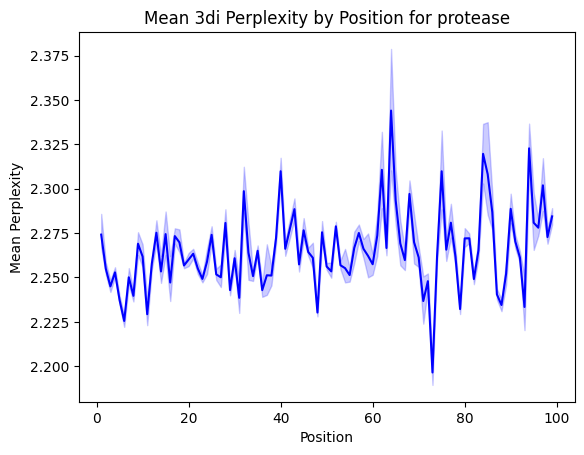

/tmp/ipykernel_998167/2892378540.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 90)` for the same effect.

  sns.lineplot(data=protein_df, x="position", y="variance_perplexity", ci=90 , color="red")


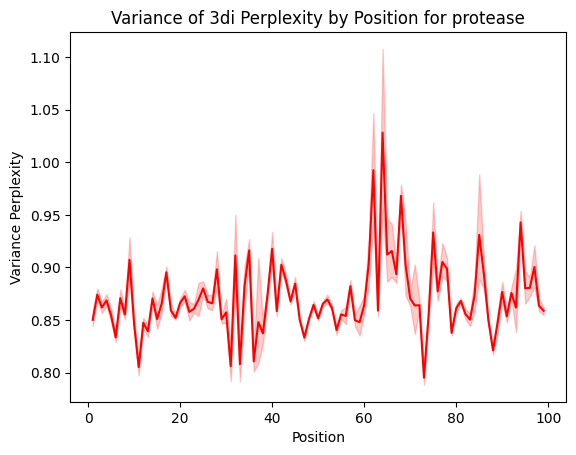

/tmp/ipykernel_998167/2892378540.py:33: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 90)` for the same effect.

  sns.lineplot(data=protein_df, x="position", y="max_perplexity", ci=90 , color="green")


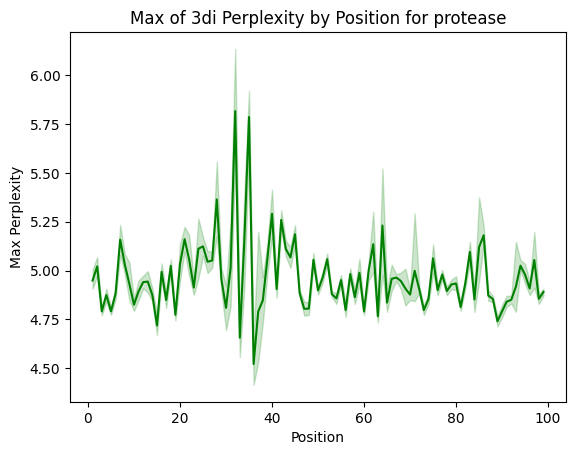

/tmp/ipykernel_998167/2892378540.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 90)` for the same effect.

  sns.lineplot(data=protein_df, x="position", y="mean_perplexity", ci=90 , color="blue")


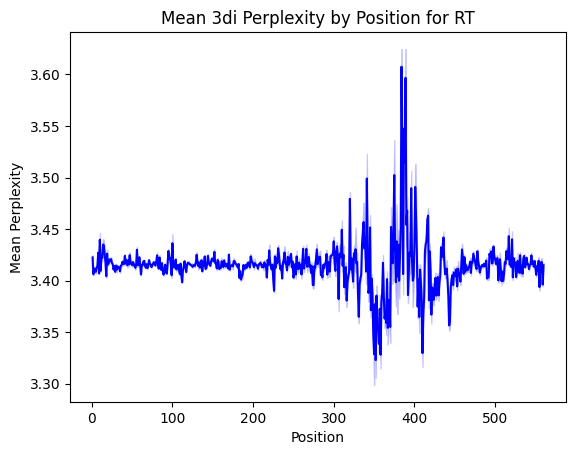

/tmp/ipykernel_998167/2892378540.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 90)` for the same effect.

  sns.lineplot(data=protein_df, x="position", y="variance_perplexity", ci=90 , color="red")


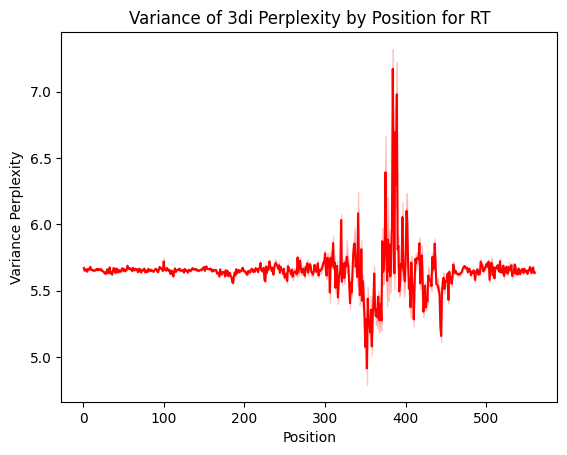

/tmp/ipykernel_998167/2892378540.py:33: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 90)` for the same effect.

  sns.lineplot(data=protein_df, x="position", y="max_perplexity", ci=90 , color="green")


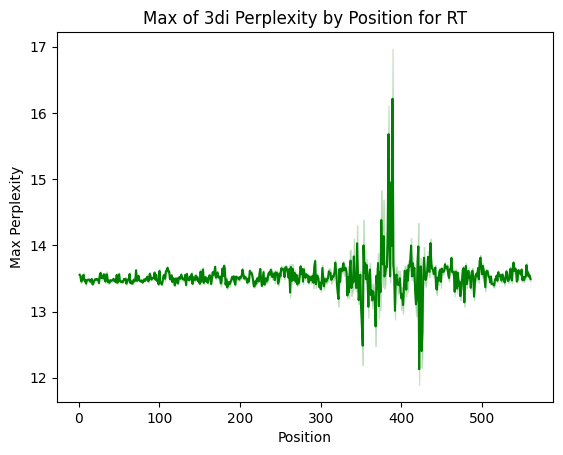

/tmp/ipykernel_998167/2892378540.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 90)` for the same effect.

  sns.lineplot(data=protein_df, x="position", y="mean_perplexity", ci=90 , color="blue")


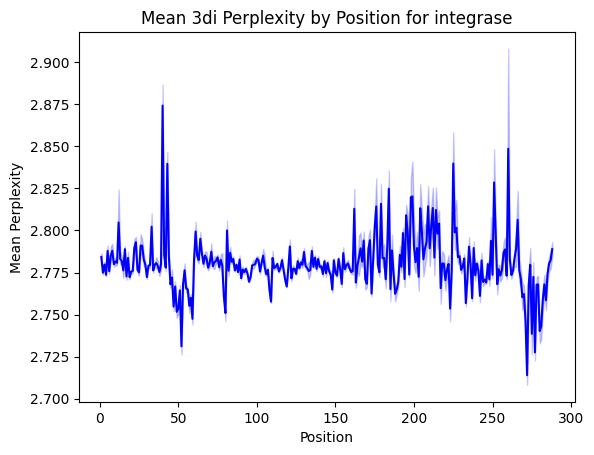

/tmp/ipykernel_998167/2892378540.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 90)` for the same effect.

  sns.lineplot(data=protein_df, x="position", y="variance_perplexity", ci=90 , color="red")


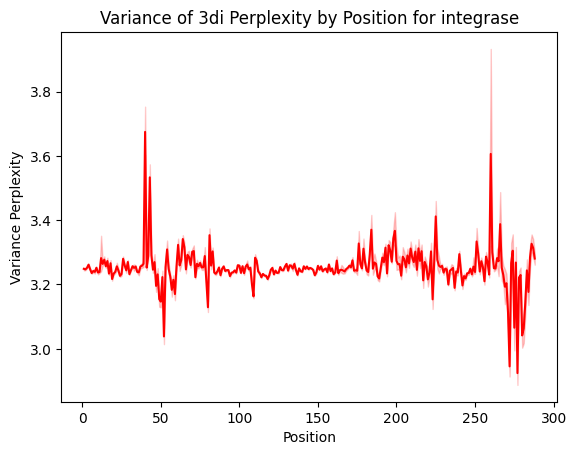

/tmp/ipykernel_998167/2892378540.py:33: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 90)` for the same effect.

  sns.lineplot(data=protein_df, x="position", y="max_perplexity", ci=90 , color="green")


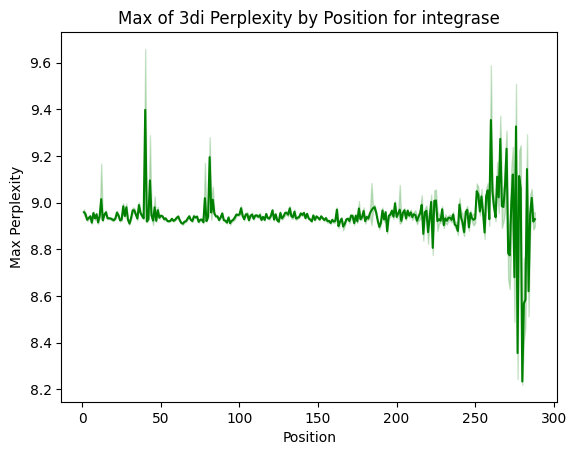

/tmp/ipykernel_998167/2892378540.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 90)` for the same effect.

  sns.lineplot(data=protein_df, x="position", y="mean_perplexity", ci=90 , color="blue")


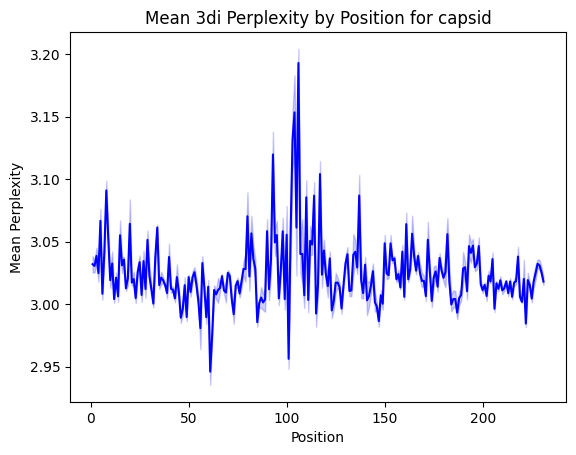

/tmp/ipykernel_998167/2892378540.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 90)` for the same effect.

  sns.lineplot(data=protein_df, x="position", y="variance_perplexity", ci=90 , color="red")


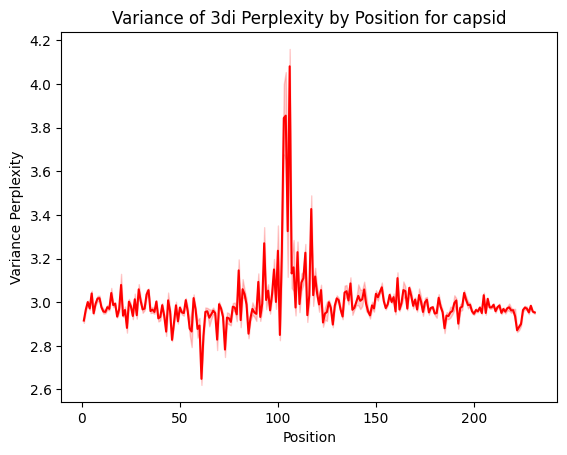

/tmp/ipykernel_998167/2892378540.py:33: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 90)` for the same effect.

  sns.lineplot(data=protein_df, x="position", y="max_perplexity", ci=90 , color="green")


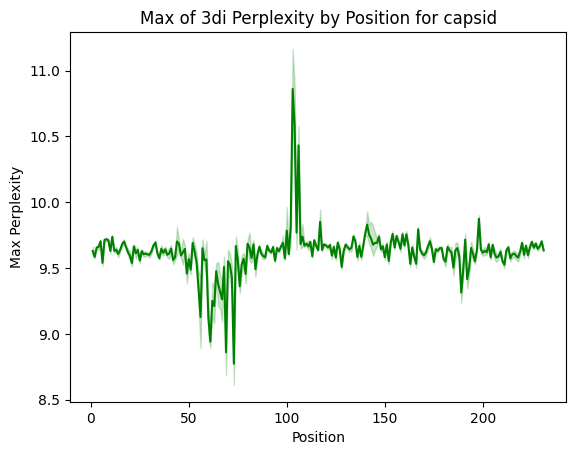

In [ ]:
import seaborn as sns
def first_existing_column(df, candidates):
	for column_name in candidates:
		if column_name in df.columns:
			return column_name
	return None

def parse_mutation_token(value):
	match = re.search(r"([A-Za-z\*])\s*(\d+)\s*([A-Za-z\*])", str(value))
	if not match:
		return None, None, None
	return match.group(1).upper(), int(match.group(2)), match.group(3).upper()

mutation_screen_df["position"] = pd.to_numeric(mutation_screen_df["position"], errors="coerce")

for protein in mutation_screen_df["sequence_id"].unique():
	native_perplexity_prot = native_perplexity_df[native_perplexity_df["sequence_id"] == protein]
	protein_df = mutation_screen_df[mutation_screen_df["sequence_id"] == protein]
	sns.lineplot(data=protein_df, x="position", y="mean_perplexity", ci=90 , color="blue")
	#sns.lineplot(data=native_perplexity_prot, x="position", y="perplexity", ci=None, color="red", label="Native")
	plt.title(f"Mean 3di Perplexity by Position for {protein}")
	plt.xlabel("Position")
	plt.ylabel("Mean Perplexity")
	plt.show()

	sns.lineplot(data=protein_df, x="position", y="variance_perplexity", ci=90 , color="red")
	plt.title(f"Variance of 3di Perplexity by Position for {protein}")
	plt.xlabel("Position")
	plt.ylabel("Variance Perplexity")
	plt.show()


	sns.lineplot(data=protein_df, x="position", y="max_perplexity", ci=90 , color="green")
	plt.title(f"Max of 3di Perplexity by Position for {protein}")
	plt.xlabel("Position")
	plt.ylabel("Max Perplexity")
	plt.show()
		